C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


 report summary stats and hotspot metrics:
count    535.00
mean       2.39
std        1.87
min        0.80
25%        1.50
50%        1.90
75%        2.60
max       20.50
Name: u_ppm, dtype: float64
 median 1.90
skewness 4.98
Hotspot threshold (95th percentile): 5.10 ppm
Number of hotspot samples: 29


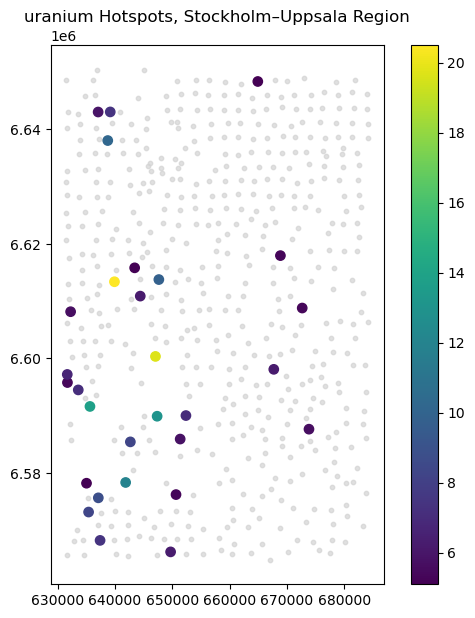

Predictor: log10(ca_ppm)
Response: log10(u_ppm)
Intercept: 0.374
Slope: -0.017
R: -0.017
R²: 0.000
P-value: 6.900e-01
Std error: 0.043


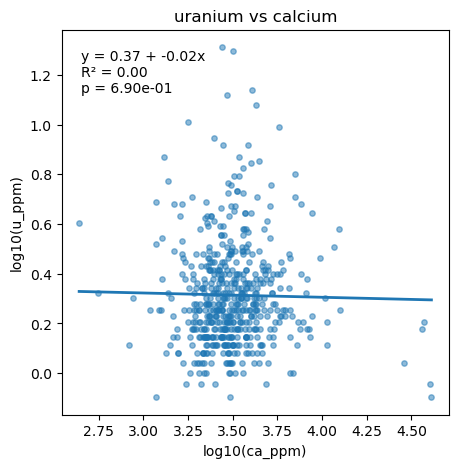

In [14]:
import geopandas as gpd
from pyproj import Transformer
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

gpd.options.io_engine = "pyogrio" #faster engine
markgeokemi_icpms = gpd.read_file(
    "C:/Projects/markgeokemi/raw_data/markgeokemi_regional.gpkg",
    layer = "moran_0063mm_hno3_icpms",
    use_arrow = True
)
#Drop rows with missing ID/coordinates, ensure SWEREF system 
markgeokemi_icpms_clean = markgeokemi_icpms.dropna(   
    subset=[
        "unikt_id", "ns", "ew", "geometry"
    ]).set_crs("EPSG:3006", allow_override=True) 
# save cleaned data to GeoPackage
markgeokemi_icpms_clean.to_file(
     "C:/Projects/markgeokemi/cleaned_data/markgeokemi_icpms_clean.gpkg",
    driver= "GPKG",
    use_arrow = True
)

#geographic bbox in WGS84; convert to SWEREF 99 TM
min_lat, max_lat = 59.20, 59.95
min_lon, max_lon = 17.30, 18.30
trans = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3006",
    always_xy = True
)
# convert bbox corners
min_ew, min_ns = trans.transform(min_lon, min_lat)  
max_ew, max_ns = trans.transform(max_lon, max_lat)

# keep valid (measured, >0) uranium values within defined bbox
#0 → removes 0 (not analyzed
u_stoch_upp = markgeokemi_icpms_clean[
    (markgeokemi_icpms_clean["u_ppm"].notna()) & #removes missing values
    (markgeokemi_icpms_clean["u_ppm"] > 0) & # > 0 removes not analysed & below detection
    (markgeokemi_icpms_clean["ew"].between(min_ew, max_ew)) &
    (markgeokemi_icpms_clean["ns"].between(min_ns, max_ns))
][["unikt_id", "ns", "ew", "u_ppm", "geometry"]
].copy()

#summary stats for defined bbox
u_stoch_upp_stat = u_stoch_upp["u_ppm"].describe()
median_u_stoch_upp = u_stoch_upp["u_ppm"].median()
skew_u_stoch_upp = u_stoch_upp["u_ppm"].skew()

# define 95th percentile threshold; select top 5% (hotspots)
thresh_95 = u_stoch_upp["u_ppm"].quantile(0.95)
u_stoch_upp_hotspots = u_stoch_upp[
    u_stoch_upp["u_ppm"] >= thresh_95
].copy()
#report summary stats and hotspot metrics
print(f" report summary stats and hotspot metrics:")
print(u_stoch_upp_stat.round(2))
print(f" median {median_u_stoch_upp:.2f}")
print(f"skewness {skew_u_stoch_upp:.2f}")
print(f"Hotspot threshold (95th percentile): {thresh_95:.2f} ppm")
print(f"Number of hotspot samples: {len(u_stoch_upp_hotspots)}")

fig, ax = plt.subplots(figsize=(7, 7))
u_stoch_upp.plot(
    ax=ax,
    color="lightgrey",
    markersize=10,
    alpha=0.7
)
u_stoch_upp_hotspots.plot(
    column="u_ppm",
    legend=True,
    ax=ax,
    markersize=45
)
ax.set_title("uranium Hotspots, Stockholm–Uppsala Region")
plt.savefig(
    "C:/Projects/markgeokemi/results/uranium_stockholm_Uppsala_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#ca data 
ca_stoch_upp = markgeokemi_icpms_clean[
    (markgeokemi_icpms_clean["ca_ppm"].notna()) & #removes missing values
    (markgeokemi_icpms_clean["ca_ppm"] > 0) & # > 0 removes not analysed & below detection
    (markgeokemi_icpms_clean["ew"].between(min_ew, max_ew)) &
    (markgeokemi_icpms_clean["ns"].between(min_ns, max_ns))
][["unikt_id", "ns", "ew", "ca_ppm", "geometry"]
].copy()
# pair u and ca correctly by sample ID
df = u_stoch_upp.merge(
    ca_stoch_upp[["unikt_id", "ca_ppm"]],
    on="unikt_id",
    how="inner"
)

# keep only positive values for log10
df = df[(df["u_ppm"] > 0) & (df["ca_ppm"] > 0)].copy()

# predictor and response
x = np.log10(df["ca_ppm"])   # predictor
y = np.log10(df["u_ppm"])   # response

# linear model
res = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = res.intercept + res.slope * x_line

# print parameters
print("Predictor: log10(ca_ppm)")
print("Response: log10(u_ppm)")
print(f"Intercept: {res.intercept:.3f}")
print(f"Slope: {res.slope:.3f}")
print(f"R: {res.rvalue:.3f}")
print(f"R²: {res.rvalue**2:.3f}")
print(f"P-value: {res.pvalue:.3e}")
print(f"Std error: {res.stderr:.3f}")

# plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=15, alpha=0.5)
ax.plot(x_line, y_line, linewidth=2)

ax.set_xlabel("log10(ca_ppm)")
ax.set_ylabel("log10(u_ppm)")
ax.set_title("uranium vs calcium")

ax.text(
    0.05, 0.95,
    f"y = {res.intercept:.2f} + {res.slope:.2f}x\nR² = {res.rvalue**2:.2f}\np = {res.pvalue:.2e}",
    transform=ax.transAxes,
    verticalalignment="top"
)

plt.savefig(
    "C:/Projects/markgeokemi/results/u_ca_stockholm_Uppsala.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()